In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import lightgbm as lgb

print("SHAP version:", shap.__version__)
print("LightGBM version:", lgb.__version__)

SHAP version: 0.52.0
LightGBM version: 4.7.0


In [2]:
import os

data_path = "../data"

files = sorted(os.listdir(data_path))

for file in files:
    print(file)

.DS_Store
HomeCredit_columns_description.csv
POS_CASH_balance.csv
X_test_final_processed.pkl
X_test_processed.pkl
X_train_final_processed.pkl
X_train_processed.pkl
X_val_final_processed.pkl
X_val_processed.pkl
application_enhanced.csv
application_test.csv
application_train.csv
bureau.csv
bureau_balance.csv
credit_card_balance.csv
final_feature_names.pkl
installments_payments.csv
preprocessor.pkl
previous_application.csv
sample_submission.csv
y_test.pkl
y_test_final.pkl
y_train.pkl
y_train_final.pkl
y_val.pkl
y_val_final.pkl


In [3]:
import joblib
import numpy as np
import pandas as pd

# Load processed datasets
X_train = joblib.load("../data/X_train_final_processed.pkl")
X_val = joblib.load("../data/X_val_final_processed.pkl")
X_test = joblib.load("../data/X_test_final_processed.pkl")

y_train = joblib.load("../data/y_train_final.pkl")
y_val = joblib.load("../data/y_val_final.pkl")
y_test = joblib.load("../data/y_test_final.pkl")

# Load actual feature names
feature_names = joblib.load("../data/final_feature_names.pkl")

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)
print("Test data:", X_test.shape)
print("Number of feature names:", len(feature_names))

Training data: (184506, 422)
Validation data: (61502, 422)
Test data: (61503, 422)
Number of feature names: 422


In [4]:
import lightgbm as lgb
import numpy as np

# Combine training and validation data
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

# Recreate the final LightGBM model
final_model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=731,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

# Train on the complete training + validation data
final_model.fit(
    X_train_full,
    y_train_full
)

print("Final LightGBM model trained successfully!")
print("Training samples:", X_train_full.shape[0])
print("Features:", X_train_full.shape[1])

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.071454 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 30783
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 406
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Final LightGBM model trained successfully!
Training samples: 246008
Features: 422


In [5]:
# Create SHAP TreeExplainer for the trained LightGBM model
explainer = shap.TreeExplainer(final_model)

print("SHAP TreeExplainer created successfully!")

SHAP TreeExplainer created successfully!


In [6]:
# Use a representative sample of the test set
np.random.seed(42)

sample_size = 2000

sample_indices = np.random.choice(
    X_test.shape[0],
    size=sample_size,
    replace=False
)

X_shap = X_test[sample_indices]

print("SHAP sample shape:", X_shap.shape)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap)

print("SHAP values generated successfully!")
print("SHAP values shape:", np.array(shap_values).shape)

SHAP sample shape: (2000, 422)
SHAP values generated successfully!
SHAP values shape: (2000, 422)


/Users/arnav/Desktop/AI-Finance-Research/.venv/lib/python3.13/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


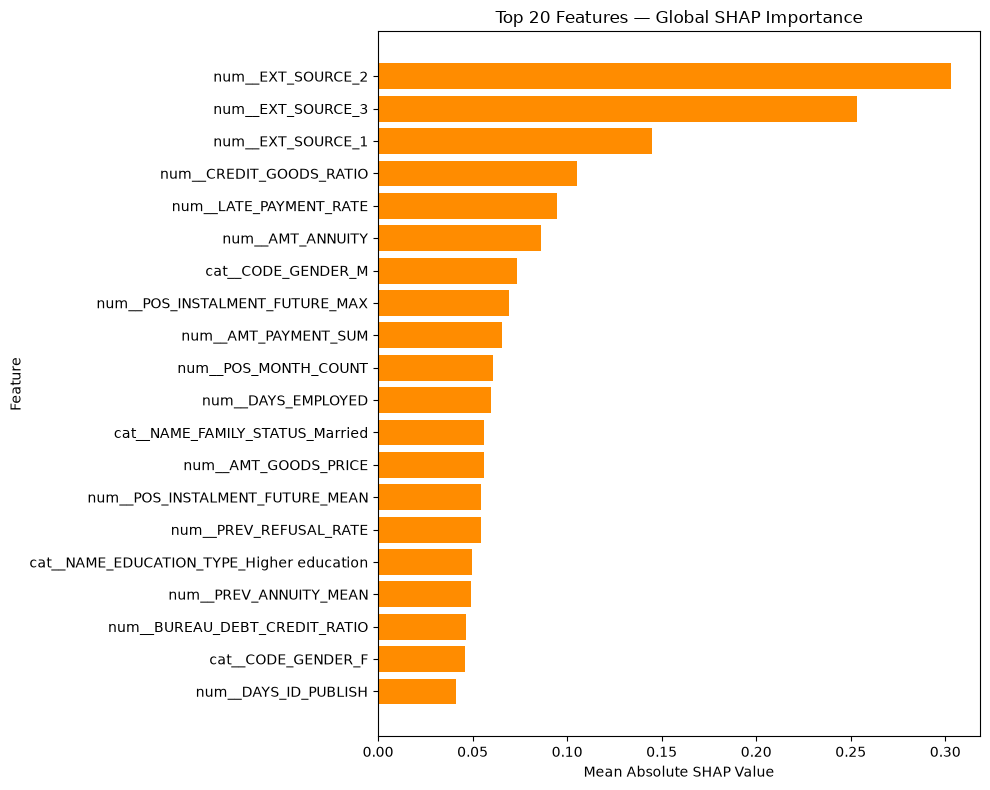

In [7]:
# Create SHAP feature-importance values
shap_importance = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": shap_importance
})

# Select top 20 features
top_shap_features = shap_importance_df.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).head(20)

# Plot
plt.figure(figsize=(10, 8))

plt.barh(
    top_shap_features["Feature"][::-1],
    top_shap_features["Mean_Absolute_SHAP"][::-1],
    color="darkorange"
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 20 Features — Global SHAP Importance")

plt.tight_layout()
plt.show()

This graph answers:

“Which features have the greatest overall influence on the model's predictions?”

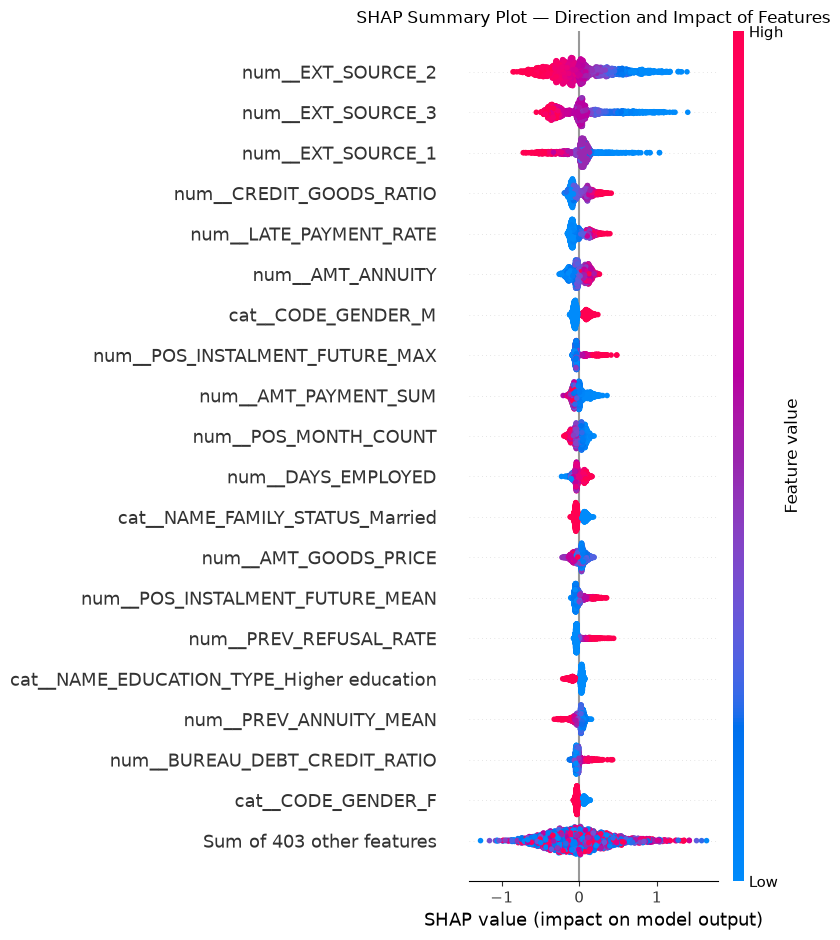

In [8]:
# Create SHAP Explanation object
shap_explanation = shap.Explanation(
    values=shap_values,
    data=X_shap,
    feature_names=feature_names
)

# SHAP beeswarm plot
plt.figure(figsize=(11, 9))

shap.plots.beeswarm(
    shap_explanation,
    max_display=20,
    show=False
)

plt.title("SHAP Summary Plot — Direction and Impact of Features")

plt.tight_layout()
plt.show()

In [9]:
# Find an applicant with a high predicted default probability
test_probabilities = final_model.predict_proba(X_test)[:, 1]

applicant_index = np.argmax(test_probabilities)

X_applicant = X_test[applicant_index:applicant_index + 1]

applicant_probability = test_probabilities[applicant_index]

print("Selected Applicant Index:", applicant_index)
print(f"Predicted Default Probability: {applicant_probability:.4f}")

Selected Applicant Index: 26965
Predicted Default Probability: 0.8683


/Users/arnav/Desktop/AI-Finance-Research/.venv/lib/python3.13/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


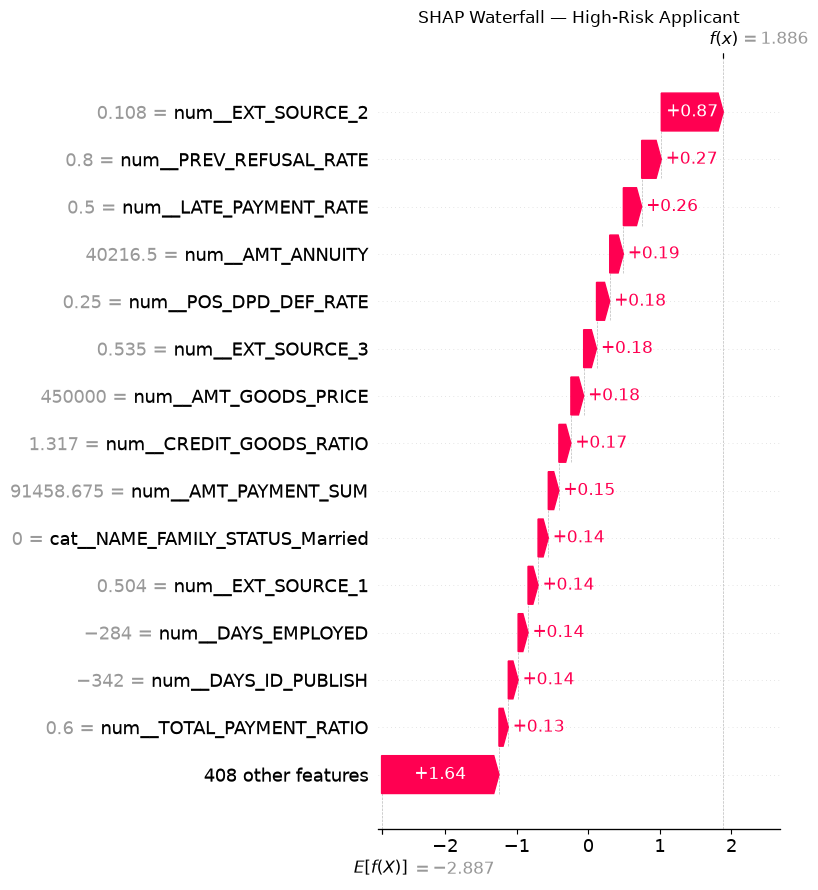

In [10]:
# Calculate SHAP values for the selected applicant
applicant_shap_values = explainer.shap_values(X_applicant)

# Handle SHAP's output format
if isinstance(applicant_shap_values, list):
    applicant_shap_values = applicant_shap_values[1]

applicant_shap_values = np.array(applicant_shap_values)

# Create SHAP Explanation object
applicant_explanation = shap.Explanation(
    values=applicant_shap_values[0],
    base_values=explainer.expected_value,
    data=X_applicant[0],
    feature_names=feature_names
)

# Waterfall plot
plt.figure(figsize=(11, 8))

shap.plots.waterfall(
    applicant_explanation,
    max_display=15,
    show=False
)

plt.title("SHAP Waterfall — High-Risk Applicant")

plt.tight_layout()
plt.show()

In [11]:
# Find an applicant with a low predicted default probability
low_risk_index = np.argmin(test_probabilities)

X_low_risk = X_test[low_risk_index:low_risk_index + 1]

low_risk_probability = test_probabilities[low_risk_index]

print("Selected Low-Risk Applicant Index:", low_risk_index)
print(f"Predicted Default Probability: {low_risk_probability:.4f}")

Selected Low-Risk Applicant Index: 60317
Predicted Default Probability: 0.0029


/Users/arnav/Desktop/AI-Finance-Research/.venv/lib/python3.13/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


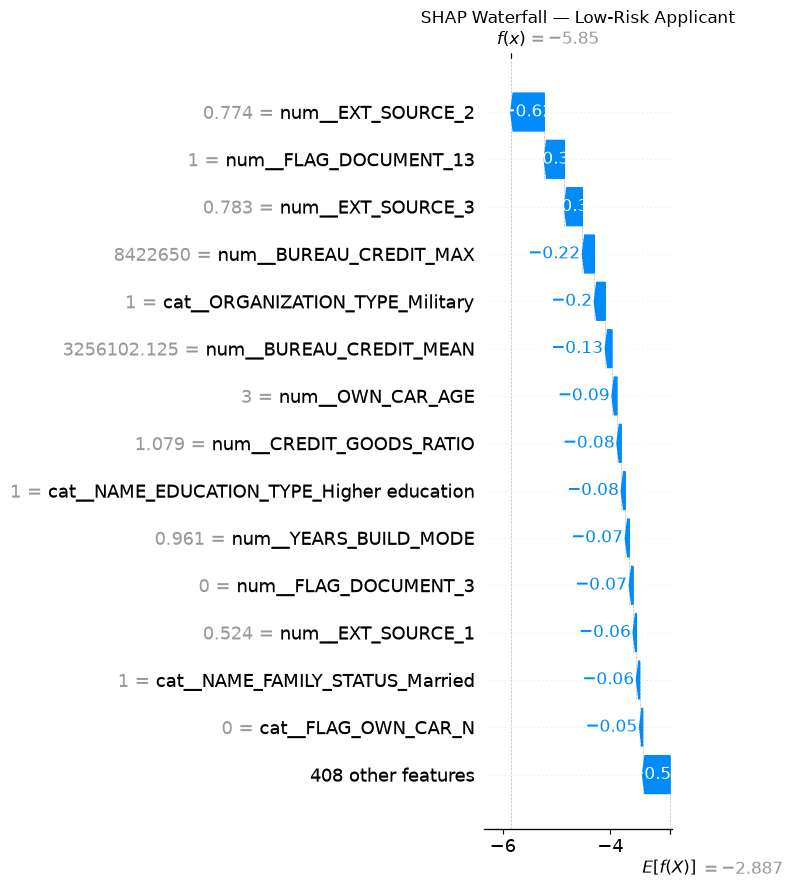

In [12]:
# Calculate SHAP values for the low-risk applicant
low_risk_shap_values = explainer.shap_values(X_low_risk)

# Handle SHAP output format
if isinstance(low_risk_shap_values, list):
    low_risk_shap_values = low_risk_shap_values[1]

low_risk_shap_values = np.array(low_risk_shap_values)

# Create SHAP Explanation object
low_risk_explanation = shap.Explanation(
    values=low_risk_shap_values[0],
    base_values=explainer.expected_value,
    data=X_low_risk[0],
    feature_names=feature_names
)

# Waterfall plot
plt.figure(figsize=(11, 8))

shap.plots.waterfall(
    low_risk_explanation,
    max_display=15,
    show=False
)

plt.title("SHAP Waterfall — Low-Risk Applicant")

plt.tight_layout()
plt.show()

<Figure size 1000x700 with 0 Axes>

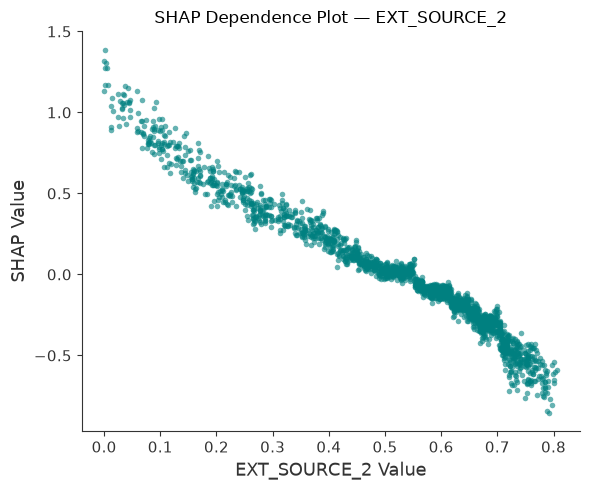

In [13]:
# SHAP dependence plot for the most important feature
plt.figure(figsize=(10, 7))

shap.dependence_plot(
    "num__EXT_SOURCE_2",
    shap_values,
    X_shap,
    feature_names=feature_names,
    interaction_index=None,
    color="teal",
    alpha=0.6,
    show=False
)

plt.title("SHAP Dependence Plot — EXT_SOURCE_2")
plt.xlabel("EXT_SOURCE_2 Value")
plt.ylabel("SHAP Value")

plt.tight_layout()
plt.show()

## SHAP Explainability — Final Summary

SHAP was used to interpret the predictions of the final LightGBM credit-risk model at both global and individual levels.

### Global Feature Importance

The global SHAP analysis identified the most influential features in the model. The strongest contributors included:

- EXT_SOURCE_2
- EXT_SOURCE_3
- EXT_SOURCE_1
- CREDIT_GOODS_RATIO
- LATE_PAYMENT_RATE
- AMT_ANNUITY
- POS_INSTALMENT_FUTURE_MAX
- AMT_PAYMENT_SUM
- POS_MONTH_COUNT
- DAYS_EMPLOYED

Both application-level information and historical credit-behaviour features contributed substantially to the model's predictions.

### Direction of Feature Impact

The SHAP summary plot showed that lower external-source scores generally contributed positively to default-risk predictions, while higher external-source scores generally contributed negatively.

The SHAP dependence analysis for EXT_SOURCE_2 demonstrated this relationship clearly: as EXT_SOURCE_2 increased, its SHAP contribution generally decreased, indicating lower predicted default risk.

### Individual Applicant Explanations

Two individual applicants were examined using SHAP waterfall plots.

**High-Risk Applicant**
- Predicted default probability: **86.83%**
- Major risk-increasing contributors included EXT_SOURCE_2, PREV_REFUSAL_RATE, LATE_PAYMENT_RATE, AMT_ANNUITY, POS_DPD_DEF_RATE, and EXT_SOURCE_3.

**Low-Risk Applicant**
- Predicted default probability: **0.29%**
- Several features, particularly EXT_SOURCE_2 and EXT_SOURCE_3, contributed negatively to the model output, reducing the predicted default risk.

### Conclusion

The SHAP analysis makes the LightGBM model more interpretable by showing both the features that influence predictions and the direction of their influence. This provides transparency at both the population level and the individual applicant level.

The explainability results demonstrate how the proposed system can support credit-risk assessment while providing understandable reasons behind model predictions.